# Task 3

Due to the simplicity of KNN for Classification, let's focus on using a Pipeline and a GridSearchCV tool, since these skills can be generalized for any model.


## The Sonar Data

### Detecting a Rock or a Mine

Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels.



The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine).



Our main goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.


Data Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

### Complete the Tasks in bold

**TASK: Run the cells below to load the data.**

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('sonar.all-data.csv')

In [3]:
df

,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,Freq_7,Freq_8,Freq_9,Freq_10,...,Freq_52,Freq_53,Freq_54,Freq_55,Freq_56,Freq_57,Freq_58,Freq_59,Freq_60,Label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


## Train | Test Split

Our approach here will be one of using Cross Validation on 90% of the dataset, and then judging our results on a final test set of 10% to evaluate our model.

**TASK: Split the data into features and labels, and then split into a training set and test set, with 90% for Cross-Validation training, and 10% for a final test set.**

*Note: The solution uses a random_state=42*

In [4]:
from sklearn.model_selection import train_test_split

# Separate features (60 sonar readings) from the target label
X = df.drop('Label', axis=1)
y = df['Label']

In [5]:
# 90% for cross-validation training, 10% held out as final test set
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## Elbow Method

Use the Elbow Method to find the optimal value of K. Scale the training and test data, then loop through k=1 to 29, fit a knn model for each k, and plot the error rate (1 - F1 score) vs. k to identify the best value.**

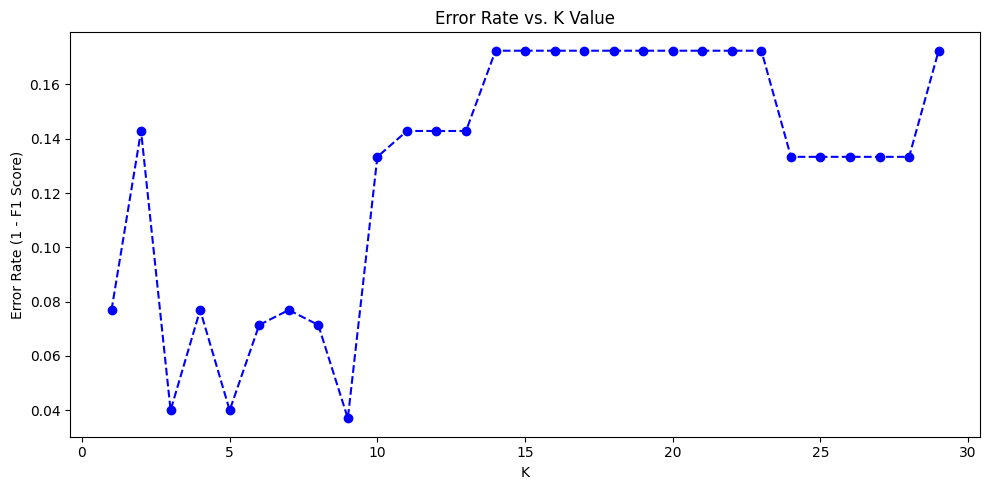

In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

# scale features: fit on training data only, then apply same transform to test. This prevents data leakage from the test set into the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

error_rates = []

# loop over k=1 to 29, recording error rate (1 - F1) for each k
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds_k = knn.predict(X_test_scaled)
    error_rates.append(1 - f1_score(y_test, preds_k, pos_label='M'))

# plot error rate vs. k — the 'elbow' indicates the optimal k before overfitting begins
plt.figure(figsize=(10, 5))
plt.plot(range(1, 30), error_rates, marker='o', color='blue', linestyle='--')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate (1 - F1 Score)')
plt.tight_layout()
plt.show()

**TASK: Create a Pipeline that contains both a StandardScaler and a KNN model**

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# pipeline chains scaling and knn together — ensures the scaler is always fit only on training data during cross-validation, avoiding data leakage
pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

**TASK: Perform a grid-search with the pipeline to test various values of k and report back the best performing parameters.**

In [8]:
from sklearn.model_selection import GridSearchCV

# Test every k from 1 to 29 using 5-fold cross-validation
# GridSearchCV automatically finds the k with the highest mean accuracy
param_grid = {'knn__n_neighbors': list(range(1, 30))}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29]},
             scoring='accuracy')

In [9]:
# best k found by GridSearchCV — the value that gave highest cross-validated accuracy
grid.best_params_

{'knn__n_neighbors': 1}

In [10]:
# best mean cross-validation accuracy across the 5 folds
grid.best_score_

np.float64(0.8453769559032717)

### Final Model Evaluation

**TASK: Using the grid classifier object from the previous step, get a final performance classification report and confusion matrix.**

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions on the held-out test set using the best model from GridSearchCV
preds = grid.predict(X_test)

In [12]:
# confusion matrix: rows = actual class, columns = predicted class shows counts of TP, TN, FP, FN for Mine (M) and Rock (R)
print(confusion_matrix(y_test, preds))

[[12  1]
 [ 1  7]]


In [13]:
# full classification report: precision, recall, F1-score per class and overall accuracy on the final test set
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           M       0.92      0.92      0.92        13
           R       0.88      0.88      0.88         8

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21

